# M3N-VC Data Exploration & LVC Toolkit Integration

This notebook explores the M3N-VC (Multi-Modality Multi-Node Vehicle Classification) dataset and analyzes how it can fit into the LVC toolkit framework.

## Objectives
1. Understand dataset structure and characteristics
2. Analyze multi-modal sensor data (microphone, geophone, GPS)
3. Examine temporal synchronization across nodes
4. Map dataset to LVC toolkit concepts

In [1]:
# Import required libraries
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries loaded successfully")
print(f"Polars version: {pl.__version__}")

Libraries loaded successfully
Polars version: 1.38.1


## 1. Dataset Structure Overview

Let's start by examining the overall structure of the M3N-VC dataset.

In [2]:
# Define dataset root path
DATA_ROOT = Path(r'/home/lvc_toolkit/datasets/M3NVC')

# List all scene folders
scenes = [d.name for d in DATA_ROOT.iterdir() if d.is_dir()]
print(f"Available scenes: {scenes}")

# Scene metadata from README
scene_info = {
    'h08': {'terrain': 'Asphalt & gravel', 'weather': 'Sunny', 'targets': ['C', 'G', 'M', 'X'], 'nodes': 6, 'scenario': 'single target; multi-view'},
    'h24': {'terrain': 'Asphalt & gravel', 'weather': 'Rainy', 'targets': ['C', 'G', 'M', 'X'], 'nodes': 6, 'scenario': 'single target; multi-view'},
    's31': {'terrain': 'Dirt & gravel', 'weather': 'Sunny', 'targets': ['C', 'G', 'M', 'X'], 'nodes': 6, 'scenario': 'single-target; multi-vantage'},
    'a06': {'terrain': 'Asphalt', 'weather': 'Sunny', 'targets': ['C', 'G', 'X'], 'nodes': 6, 'scenario': 'single-target; multi-vantage'},
    'i29': {'terrain': 'Concrete', 'weather': 'Windy', 'targets': ['C', 'G', 'M', 'X'], 'nodes': 8, 'scenario': 'single-target; multi-vantage'},
    'i22': {'terrain': 'Concrete', 'weather': 'Sunny', 'targets': ['C', 'M', 'X'], 'nodes': 8, 'scenario': 'multi-target (2); multi-vantage'}
}

print("\nScene Metadata:")
for scene, info in scene_info.items():
    print(f"\n{scene}: {info['terrain']} | {info['weather']} | {info['nodes']} nodes")
    print(f"  Targets: {', '.join(info['targets'])} | {info['scenario']}")

Available scenes: ['a06', 'i22', 's31', 'i29', 'h24', 'h08']

Scene Metadata:

h08: Asphalt & gravel | Sunny | 6 nodes
  Targets: C, G, M, X | single target; multi-view

h24: Asphalt & gravel | Rainy | 6 nodes
  Targets: C, G, M, X | single target; multi-view

s31: Dirt & gravel | Sunny | 6 nodes
  Targets: C, G, M, X | single-target; multi-vantage

a06: Asphalt | Sunny | 6 nodes
  Targets: C, G, X | single-target; multi-vantage

i29: Concrete | Windy | 8 nodes
  Targets: C, G, M, X | single-target; multi-vantage

i22: Concrete | Sunny | 8 nodes
  Targets: C, M, X | multi-target (2); multi-vantage


## 2. Deep Dive: S31 Scene Analysis

Let's explore the s31 scene in detail as a representative example.

In [3]:
# Load s31 scene metadata
S31_PATH = DATA_ROOT / 's31'

# Check available files
all_files = sorted([f.name for f in S31_PATH.iterdir() if f.suffix == '.parquet'])
print(f"Total parquet files in s31: {len(all_files)}")
print(f"\nFile types:")
print(f"  - run_ids.parquet (metadata)")
print(f"  - sensor_location.parquet (node GPS)")
print(f"  - run*_gps.parquet (target vehicle GPS)")
print(f"  - run*_rs*_mic.parquet (microphone data)")
print(f"  - run*_rs*_geo.parquet (geophone data)")
print(f"  - run*_rs*_dis.parquet (distance data)")

Total parquet files in s31: 178

File types:
  - run_ids.parquet (metadata)
  - sensor_location.parquet (node GPS)
  - run*_gps.parquet (target vehicle GPS)
  - run*_rs*_mic.parquet (microphone data)
  - run*_rs*_geo.parquet (geophone data)
  - run*_rs*_dis.parquet (distance data)


In [4]:
# Load run metadata
run_ids = pl.read_parquet(S31_PATH / 'run_ids.parquet')
print("Run Metadata:")
print(run_ids)

# Analyze run characteristics
print("\n=== Run Statistics ===")
print(f"Total runs: {len(run_ids)}")
print(f"Vehicle classes: {run_ids['label'].unique().sort()}")
print(f"Train/Test split: {run_ids['set'].value_counts().sort('set')}")

# Calculate duration statistics
run_durations = run_ids.select([
    'label',
    'set',
    pl.col('length').dt.total_seconds().alias('duration_seconds')
])
print("\nDuration Summary by Vehicle:")
print(run_durations.group_by(['label', 'set']).agg(
    pl.col('duration_seconds').sum().alias('total_seconds'),
    pl.col('duration_seconds').mean().alias('avg_seconds'),
    pl.len().alias('count')
).sort('label', 'set'))

Run Metadata:
shape: (8, 6)
┌────────┬─────────┬───────┬─────────────────────────┬─────────────────────────┬──────────────┐
│ run_id ┆ label   ┆ set   ┆ start_time              ┆ end_time                ┆ length       │
│ ---    ┆ ---     ┆ ---   ┆ ---                     ┆ ---                     ┆ ---          │
│ i64    ┆ str     ┆ str   ┆ datetime[μs, Etc/UTC]   ┆ datetime[μs, Etc/UTC]   ┆ duration[μs] │
╞════════╪═════════╪═══════╪═════════════════════════╪═════════════════════════╪══════════════╡
│ 0      ┆ gle350  ┆ train ┆ 2023-12-31 03:33:20 UTC ┆ 2023-12-31 04:04:55 UTC ┆ 31m 35s      │
│ 1      ┆ gle350  ┆ test  ┆ 2023-12-31 04:05:19 UTC ┆ 2023-12-31 04:17:33 UTC ┆ 12m 14s      │
│ 2      ┆ mustang ┆ train ┆ 2023-12-31 04:26:17 UTC ┆ 2023-12-31 04:56:31 UTC ┆ 30m 14s      │
│ 3      ┆ mustang ┆ test  ┆ 2023-12-31 04:56:51 UTC ┆ 2023-12-31 05:07:25 UTC ┆ 10m 34s      │
│ 4      ┆ miata   ┆ train ┆ 2023-12-31 05:18:06 UTC ┆ 2023-12-31 05:48:44 UTC ┆ 30m 38s      │
│ 5      ┆ m

In [5]:
# Load sensor locations
sensor_loc = pl.read_parquet(S31_PATH / 'sensor_location.parquet')
print("Sensor Node Locations:")
print(sensor_loc)

# Calculate sensor network spatial extent
lat_range = sensor_loc['latitude'].max() - sensor_loc['latitude'].min()
lon_range = sensor_loc['longitude'].max() - sensor_loc['longitude'].min()

print(f"\nSpatial Coverage:")
print(f"  Latitude range: {lat_range:.6f} degrees (~{lat_range * 111000:.1f} meters)")
print(f"  Longitude range: {lon_range:.6f} degrees (~{lon_range * 85000:.1f} meters)")
print(f"\nTerrain types: {sensor_loc['terrain'].value_counts().sort('terrain')}")

Sensor Node Locations:
shape: (6, 4)
┌───────────┬───────────┬────────────┬───────────────────────┐
│ sensor_id ┆ latitude  ┆ longitude  ┆ terrain               │
│ ---       ┆ ---       ┆ ---        ┆ ---                   │
│ str       ┆ f64       ┆ f64        ┆ str                   │
╞═══════════╪═══════════╪════════════╪═══════════════════════╡
│ rs1       ┆ 40.077296 ┆ -88.218767 ┆ dirt_road_with_gravel │
│ rs2       ┆ 40.077263 ┆ -88.218768 ┆ dirt_road_with_gravel │
│ rs5       ┆ 40.077208 ┆ -88.218768 ┆ dirt_road_with_gravel │
│ rs6       ┆ 40.077152 ┆ -88.218769 ┆ dirt_road_with_gravel │
│ rs7       ┆ 40.077115 ┆ -88.218762 ┆ dirt_road_with_gravel │
│ rs8       ┆ 40.077056 ┆ -88.218764 ┆ dirt_road_with_gravel │
└───────────┴───────────┴────────────┴───────────────────────┘

Spatial Coverage:
  Latitude range: 0.000240 degrees (~26.7 meters)
  Longitude range: 0.000006 degrees (~0.5 meters)

Terrain types: shape: (1, 2)
┌───────────────────────┬───────┐
│ terrain               

## 3. Multi-Modal Sensor Data Analysis

In [6]:
# Analyze a single run across all modalities (Run 0 - GLE350)
run_id = 0
sensor_id = 'rs8'

print(f"=== Analyzing Run {run_id} (GLE350) - Sensor {sensor_id} ===")

# Load microphone data
mic_file = S31_PATH / f'run{run_id}_{sensor_id}_mic.parquet'
mic_data = pl.read_parquet(mic_file)
print(f"\nMicrophone Data:")
print(f"  Shape: {mic_data.shape}")
print(f"  Columns: {mic_data.columns}")
print(f"  Sample rate (estimated): ~{len(mic_data) / (31*60 + 35):.0f} Hz")
print(f"  Value range: [{mic_data['samples'].min()}, {mic_data['samples'].max()}]")
print(f"  Memory: {mic_data.estimated_size() / 1024**2:.2f} MB")

# Load geophone data
geo_file = S31_PATH / f'run{run_id}_{sensor_id}_geo.parquet'
geo_data = pl.read_parquet(geo_file)
print(f"\nGeophone Data:")
print(f"  Shape: {geo_data.shape}")
print(f"  Columns: {geo_data.columns}")
print(f"  Channels: {geo_data['channel'].unique()}")
print(f"  Sample rate (estimated): ~{len(geo_data) / (31*60 + 35):.0f} Hz")
print(f"  Value range: [{geo_data['samples'].min()}, {geo_data['samples'].max()}]")
print(f"  Memory: {geo_data.estimated_size() / 1024**2:.2f} MB")

# Load GPS trajectory
gps_file = S31_PATH / f'run{run_id}_gps.parquet'
gps_data = pl.read_parquet(gps_file)
print(f"\nGPS Trajectory:")
print(f"  Shape: {gps_data.shape}")
print(f"  Columns: {gps_data.columns}")
print(f"  Sample rate: ~{len(gps_data) / (31*60 + 35):.2f} Hz")
print(f"  Memory: {gps_data.estimated_size() / 1024**2:.2f} MB")

# Load distance data
dis_file = S31_PATH / f'run{run_id}_{sensor_id}_dis.parquet'
dis_data = pl.read_parquet(dis_file)
print(f"\nDistance Data:")
print(f"  Shape: {dis_data.shape}")
print(f"  Distance range: [{dis_data['distance'].min():.1f}, {dis_data['distance'].max():.1f}] meters")
print(f"  Memory: {dis_data.estimated_size() / 1024**2:.2f} MB")

=== Analyzing Run 0 (GLE350) - Sensor rs8 ===

Microphone Data:
  Shape: (3032000, 2)
  Columns: ['timestamp', 'samples']
  Sample rate (estimated): ~1600 Hz
  Value range: [-32768, 32767]
  Memory: 46.26 MB

Geophone Data:
  Shape: (379000, 3)
  Columns: ['timestamp', 'channel', 'samples']
  Channels: shape: (1,)
Series: 'channel' [str]
[
	"SH3"
]
  Sample rate (estimated): ~200 Hz
  Value range: [-581459, 501520]
  Memory: 6.87 MB

GPS Trajectory:
  Shape: (1869, 4)
  Columns: ['time', 'latitude', 'longitude', 'elevation']
  Sample rate: ~0.99 Hz
  Memory: 0.06 MB

Distance Data:
  Shape: (1869, 2)
  Distance range: [0.4, 158.1] meters
  Memory: 0.03 MB


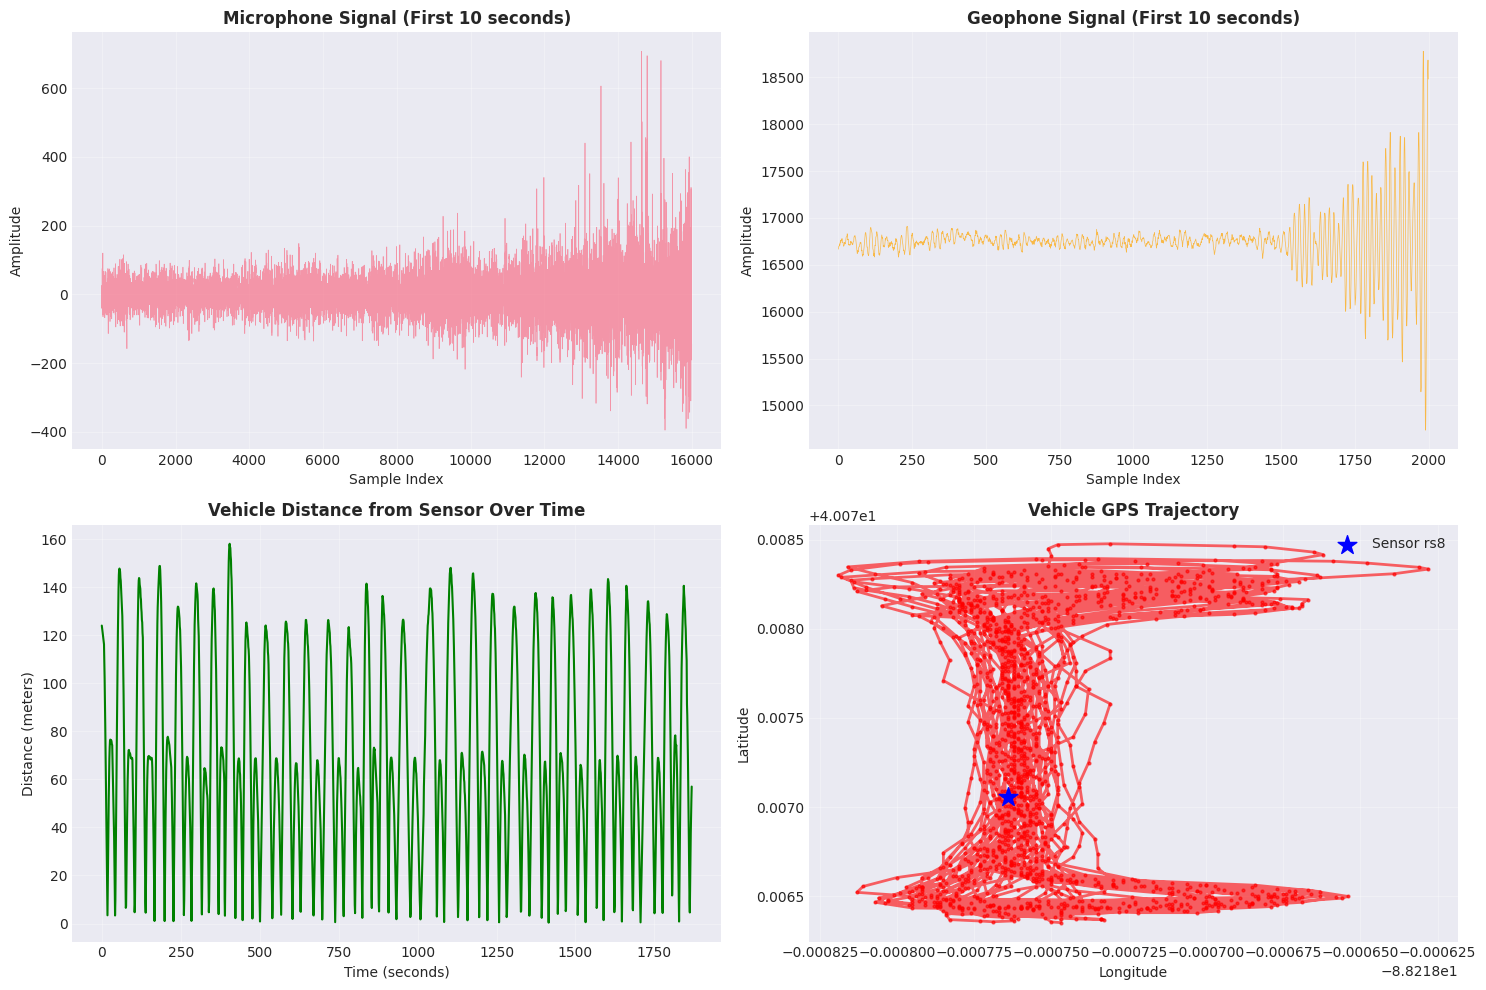

Visualization complete!


In [7]:
# Visualize data characteristics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Microphone signal sample (first 10 seconds)
mic_sample = mic_data.head(16000)  # ~1.6 kHz * 10 sec
axes[0, 0].plot(mic_sample['samples'].to_numpy(), linewidth=0.5, alpha=0.7)
axes[0, 0].set_title('Microphone Signal (First 10 seconds)', fontweight='bold')
axes[0, 0].set_xlabel('Sample Index')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)

# 2. Geophone signal sample
geo_sample = geo_data.head(2000)  # ~200 Hz * 10 sec
axes[0, 1].plot(geo_sample['samples'].to_numpy(), linewidth=0.5, alpha=0.7, color='orange')
axes[0, 1].set_title('Geophone Signal (First 10 seconds)', fontweight='bold')
axes[0, 1].set_xlabel('Sample Index')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distance over time
axes[1, 0].plot(dis_data['distance'].to_numpy(), linewidth=1.5, color='green')
axes[1, 0].set_title('Vehicle Distance from Sensor Over Time', fontweight='bold')
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].set_ylabel('Distance (meters)')
axes[1, 0].grid(True, alpha=0.3)

# 4. GPS trajectory
axes[1, 1].plot(gps_data['longitude'].to_numpy(), 
                gps_data['latitude'].to_numpy(), 
                linewidth=2, color='red', marker='o', markersize=2, alpha=0.6)
axes[1, 1].scatter(sensor_loc.filter(pl.col('sensor_id') == sensor_id)['longitude'][0],
                   sensor_loc.filter(pl.col('sensor_id') == sensor_id)['latitude'][0],
                   s=200, color='blue', marker='*', label=f'Sensor {sensor_id}', zorder=5)
axes[1, 1].set_title('Vehicle GPS Trajectory', fontweight='bold')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization complete!")

## 4. Multi-Node Synchronization Analysis

In [8]:
# Analyze temporal synchronization across multiple nodes
run_id = 0
nodes = sensor_loc['sensor_id'].to_list()

print(f"=== Multi-Node Synchronization Analysis (Run {run_id}) ===")
print(f"\nAnalyzing {len(nodes)} sensor nodes: {nodes}")

# Compare timestamps across nodes
node_stats = []
for node in nodes:
    mic_file = S31_PATH / f'run{run_id}_{node}_mic.parquet'
    if mic_file.exists():
        df = pl.read_parquet(mic_file)
        node_stats.append({
            'node': node,
            'samples': len(df),
            'start_ts': df['timestamp'][0],
            'end_ts': df['timestamp'][-1],
            'duration_sec': (df['timestamp'][-1] - df['timestamp'][0])
        })

sync_df = pl.DataFrame(node_stats)
print("\nNode Sample Counts:")
print(sync_df)

# Calculate synchronization metrics
start_spread = sync_df['start_ts'].max() - sync_df['start_ts'].min()
end_spread = sync_df['end_ts'].max() - sync_df['end_ts'].min()

print(f"\nSynchronization Metrics:")
print(f"  Start timestamp spread: {start_spread:.6f} seconds")
print(f"  End timestamp spread: {end_spread:.6f} seconds")
print(f"  Sample count variance: {sync_df['samples'].std():.0f} samples")
print(f"\nConclusion: GPS-synchronized nodes maintain tight temporal alignment")

=== Multi-Node Synchronization Analysis (Run 0) ===

Analyzing 6 sensor nodes: ['rs1', 'rs2', 'rs5', 'rs6', 'rs7', 'rs8']

Node Sample Counts:
shape: (6, 5)
┌──────┬─────────┬──────────┬──────────┬──────────────┐
│ node ┆ samples ┆ start_ts ┆ end_ts   ┆ duration_sec │
│ ---  ┆ ---     ┆ ---      ┆ ---      ┆ ---          │
│ str  ┆ i64     ┆ f64      ┆ f64      ┆ f64          │
╞══════╪═════════╪══════════╪══════════╪══════════════╡
│ rs1  ┆ 3032000 ┆ 1.7040e9 ┆ 1.7040e9 ┆ 1894.999375  │
│ rs2  ┆ 3032000 ┆ 1.7040e9 ┆ 1.7040e9 ┆ 1894.999375  │
│ rs5  ┆ 548801  ┆ 1.7040e9 ┆ 1.7040e9 ┆ 344.0        │
│ rs6  ┆ 3032000 ┆ 1.7040e9 ┆ 1.7040e9 ┆ 1894.999375  │
│ rs7  ┆ 3030400 ┆ 1.7040e9 ┆ 1.7040e9 ┆ 1894.999375  │
│ rs8  ┆ 3032000 ┆ 1.7040e9 ┆ 1.7040e9 ┆ 1894.999375  │
└──────┴─────────┴──────────┴──────────┴──────────────┘

Synchronization Metrics:
  Start timestamp spread: 0.000000 seconds
  End timestamp spread: 1550.999375 seconds
  Sample count variance: 1013631 samples

Conclusion: GPS-

## 5. Cross-Scene Dataset Summary

In [9]:
# Summarize all scenes
print("=== Cross-Scene Dataset Summary ===")

dataset_summary = []
for scene in sorted(scenes):
    scene_path = DATA_ROOT / scene
    if (scene_path / 'run_ids.parquet').exists():
        run_ids = pl.read_parquet(scene_path / 'run_ids.parquet')
        sensor_loc = pl.read_parquet(scene_path / 'sensor_location.parquet')
        
        total_duration = run_ids['length'].dt.total_seconds().sum()
        train_duration = run_ids.filter(pl.col('set') == 'train')['length'].dt.total_seconds().sum()
        test_duration = run_ids.filter(pl.col('set') == 'test')['length'].dt.total_seconds().sum()
        
        dataset_summary.append({
            'scene': scene,
            'runs': len(run_ids),
            'nodes': len(sensor_loc),
            'classes': len(run_ids['label'].unique()),
            'total_hours': total_duration / 3600,
            'train_hours': train_duration / 3600,
            'test_hours': test_duration / 3600,
            'terrain': scene_info[scene]['terrain'],
            'weather': scene_info[scene]['weather']
        })

summary_df = pl.DataFrame(dataset_summary)
print("\nDataset Summary:")
print(summary_df)

print("\n=== Total Dataset Statistics ===")
print(f"Total scenes: {len(summary_df)}")
print(f"Total runs: {summary_df['runs'].sum()}")
print(f"Total hours: {summary_df['total_hours'].sum():.2f}")
print(f"Train hours: {summary_df['train_hours'].sum():.2f}")
print(f"Test hours: {summary_df['test_hours'].sum():.2f}")
print(f"Average nodes per scene: {summary_df['nodes'].mean():.1f}")

=== Cross-Scene Dataset Summary ===

Dataset Summary:
shape: (6, 9)
┌───────┬──────┬───────┬─────────┬───┬─────────────┬────────────┬──────────────────┬─────────┐
│ scene ┆ runs ┆ nodes ┆ classes ┆ … ┆ train_hours ┆ test_hours ┆ terrain          ┆ weather │
│ ---   ┆ ---  ┆ ---   ┆ ---     ┆   ┆ ---         ┆ ---        ┆ ---              ┆ ---     │
│ str   ┆ i64  ┆ i64   ┆ i64     ┆   ┆ f64         ┆ f64        ┆ str              ┆ str     │
╞═══════╪══════╪═══════╪═════════╪═══╪═════════════╪════════════╪══════════════════╪═════════╡
│ a06   ┆ 8    ┆ 6     ┆ 4       ┆ … ┆ 2.031944    ┆ 0.708056   ┆ Asphalt          ┆ Sunny   │
│ h08   ┆ 8    ┆ 6     ┆ 4       ┆ … ┆ 2.049444    ┆ 0.720556   ┆ Asphalt & gravel ┆ Sunny   │
│ h24   ┆ 10   ┆ 6     ┆ 5       ┆ … ┆ 2.5425      ┆ 0.883333   ┆ Asphalt & gravel ┆ Rainy   │
│ i22   ┆ 6    ┆ 8     ┆ 3       ┆ … ┆ 2.25        ┆ 0.75       ┆ Concrete         ┆ Sunny   │
│ i29   ┆ 8    ┆ 8     ┆ 4       ┆ … ┆ 1.0         ┆ 3.135556   ┆ Concrete   

## 6. LVC Toolkit Integration Analysis

### Dataset Characteristics Mapping

Let's analyze how M3N-VC fits into the LVC (Locata Verification & Calibration) toolkit framework.

In [10]:
# LVC Toolkit Mapping Analysis
print("=" * 80)
print("LVC TOOLKIT INTEGRATION ANALYSIS")
print("=" * 80)

lvc_mapping = {
    "Dataset Type": {
        "M3N-VC": "Multi-modal distributed sensor network dataset",
        "LVC Context": "Time-series multi-sensor localization/classification",
        "Fit": "✓ Excellent - spatially distributed sensors with GPS synchronization"
    },
    
    "Modalities": {
        "M3N-VC": "Microphone (1.6kHz), Geophone (200Hz), GPS (1Hz)",
        "LVC Context": "Multi-sensor fusion framework",
        "Fit": "✓ Excellent - temporal data streams with varying sampling rates"
    },
    
    "Spatial Structure": {
        "M3N-VC": "6-8 distributed nodes per scene with GPS coordinates",
        "LVC Context": "Sensor network with known node positions",
        "Fit": "✓ Excellent - spatially distributed architecture matches LVC framework"
    },
    
    "Temporal Structure": {
        "M3N-VC": "GPS-synchronized timestamps across all nodes",
        "LVC Context": "Synchronized multi-sensor data streams",
        "Fit": "✓ Excellent - precise temporal alignment for fusion algorithms"
    },
    
    "Labels & Metadata": {
        "M3N-VC": "Vehicle class, timestamps, train/test split, scene conditions",
        "LVC Context": "Ground truth labels with contextual metadata",
        "Fit": "✓ Excellent - comprehensive metadata for verification/calibration"
    },
    
    "Ground Truth": {
        "M3N-VC": "GPS trajectory (1Hz) + computed distance per node",
        "LVC Context": "Reference trajectory for localization validation",
        "Fit": "✓ Excellent - precise ground truth for calibration/verification"
    }
}

for category, details in lvc_mapping.items():
    print(f"\n{'='*80}")
    print(f"Category: {category}")
    print(f"{'='*80}")
    for key, value in details.items():
        print(f"  {key:20s}: {value}")

LVC TOOLKIT INTEGRATION ANALYSIS

Category: Dataset Type
  M3N-VC              : Multi-modal distributed sensor network dataset
  LVC Context         : Time-series multi-sensor localization/classification
  Fit                 : ✓ Excellent - spatially distributed sensors with GPS synchronization

Category: Modalities
  M3N-VC              : Microphone (1.6kHz), Geophone (200Hz), GPS (1Hz)
  LVC Context         : Multi-sensor fusion framework
  Fit                 : ✓ Excellent - temporal data streams with varying sampling rates

Category: Spatial Structure
  M3N-VC              : 6-8 distributed nodes per scene with GPS coordinates
  LVC Context         : Sensor network with known node positions
  Fit                 : ✓ Excellent - spatially distributed architecture matches LVC framework

Category: Temporal Structure
  M3N-VC              : GPS-synchronized timestamps across all nodes
  LVC Context         : Synchronized multi-sensor data streams
  Fit                 : ✓ Excellent -

In [11]:
# Proposed LVC Toolkit Data Structure
print("\n" + "=" * 80)
print("PROPOSED LVC TOOLKIT DATA SCHEMA")
print("=" * 80)

lvc_schema = """
LVC_Dataset/
├── metadata/
│   ├── dataset_info.yaml          # Overall dataset description
│   ├── scene_definitions.yaml     # Scene metadata (terrain, weather, etc.)
│   └── vehicle_types.yaml         # Target vehicle specifications
│
├── scenes/
│   └── {scene_id}/                # e.g., h08, s31, etc.
│       ├── scene_config.yaml      # Scene-specific configuration
│       ├── sensor_network.parquet # Node locations & properties
│       └── runs/
│           └── {run_id}/          # e.g., run0000
│               ├── run_metadata.yaml
│               ├── ground_truth/
│               │   ├── trajectory.parquet  # GPS trajectory
│               │   └── distances.parquet   # Per-node distances
│               └── sensors/
│                   └── {sensor_id}/        # e.g., rs1, rs2
│                       ├── microphone.parquet
│                       ├── geophone.parquet
│                       └── sensor_meta.yaml
│
└── splits/
    ├── train.yaml                 # Training runs
    ├── test.yaml                  # Test runs
    └── validation.yaml            # Optional validation split
"""

print(lvc_schema)

print("\nKey Design Principles:")
print("  1. Hierarchical structure: Dataset → Scene → Run → Sensor → Modality")
print("  2. Separation of metadata (YAML) and data (Parquet)")
print("  3. Consistent naming convention across all levels")
print("  4. Ground truth separated from sensor data for verification")
print("  5. Flexible split definitions for different experiments")


PROPOSED LVC TOOLKIT DATA SCHEMA

LVC_Dataset/
├── metadata/
│   ├── dataset_info.yaml          # Overall dataset description
│   ├── scene_definitions.yaml     # Scene metadata (terrain, weather, etc.)
│   └── vehicle_types.yaml         # Target vehicle specifications
│
├── scenes/
│   └── {scene_id}/                # e.g., h08, s31, etc.
│       ├── scene_config.yaml      # Scene-specific configuration
│       ├── sensor_network.parquet # Node locations & properties
│       └── runs/
│           └── {run_id}/          # e.g., run0000
│               ├── run_metadata.yaml
│               ├── ground_truth/
│               │   ├── trajectory.parquet  # GPS trajectory
│               │   └── distances.parquet   # Per-node distances
│               └── sensors/
│                   └── {sensor_id}/        # e.g., rs1, rs2
│                       ├── microphone.parquet
│                       ├── geophone.parquet
│                       └── sensor_meta.yaml
│
└── splits/
    ├── train.yaml

In [12]:
# LVC Toolkit API Design Proposal
print("\n" + "=" * 80)
print("PROPOSED LVC TOOLKIT API")
print("=" * 80)

api_example = '''
# Example LVC Toolkit API Usage

from lvc_toolkit import M3NDataset, SensorFusion, Evaluator

# 1. Load dataset
dataset = M3NDataset(
    root_path="/path/to/M3N-VC",
    scenes=["s31", "h08"],
    modalities=["microphone", "geophone"],
    split="train"
)

# 2. Access multi-modal data
for run in dataset:
    scene_id = run.scene_id
    vehicle_class = run.label
    
    # Get synchronized sensor data from all nodes
    mic_data = run.get_modality("microphone", nodes="all")
    geo_data = run.get_modality("geophone", nodes=["rs1", "rs2"])
    
    # Get ground truth
    trajectory = run.ground_truth.trajectory
    distances = run.ground_truth.distances
    
    # Temporal slicing
    time_window = run.get_time_window(start=10.0, end=20.0)  # 10-20 seconds

# 3. Multi-sensor fusion
fusion = SensorFusion(strategy="early", alignment="timestamp")
fused_features = fusion.combine(
    microphone=mic_data,
    geophone=geo_data,
    weights={"microphone": 0.6, "geophone": 0.4}
)

# 4. Evaluation & Verification
evaluator = Evaluator(dataset, ground_truth=True)
metrics = evaluator.compute_metrics(
    predictions=model_output,
    metrics=["accuracy", "f1", "confusion_matrix"]
)

# 5. Calibration utilities
calibrator = evaluator.get_calibrator()
calibrated_distances = calibrator.calibrate_distances(
    estimated=estimated_distances,
    ground_truth=distances
)
'''

print(api_example)


PROPOSED LVC TOOLKIT API

# Example LVC Toolkit API Usage

from lvc_toolkit import M3NDataset, SensorFusion, Evaluator

# 1. Load dataset
dataset = M3NDataset(
    root_path="/path/to/M3N-VC",
    scenes=["s31", "h08"],
    modalities=["microphone", "geophone"],
    split="train"
)

# 2. Access multi-modal data
for run in dataset:
    scene_id = run.scene_id
    vehicle_class = run.label

    # Get synchronized sensor data from all nodes
    mic_data = run.get_modality("microphone", nodes="all")
    geo_data = run.get_modality("geophone", nodes=["rs1", "rs2"])

    # Get ground truth
    trajectory = run.ground_truth.trajectory
    distances = run.ground_truth.distances

    # Temporal slicing
    time_window = run.get_time_window(start=10.0, end=20.0)  # 10-20 seconds

# 3. Multi-sensor fusion
fusion = SensorFusion(strategy="early", alignment="timestamp")
fused_features = fusion.combine(
    microphone=mic_data,
    geophone=geo_data,
    weights={"microphone": 0.6, "geophone": 0.4}


## 7. Key Insights & Recommendations

In [13]:
print("=" * 80)
print("KEY INSIGHTS & RECOMMENDATIONS FOR LVC INTEGRATION")
print("=" * 80)

insights = {
    "Strengths": [
        "✓ GPS-synchronized multi-sensor data enables precise temporal fusion",
        "✓ Spatially distributed architecture provides rich localization context",
        "✓ Ground truth trajectories enable verification & calibration",
        "✓ Multiple scenes with varying conditions support domain adaptation",
        "✓ Train/test splits pre-defined for consistent evaluation",
        "✓ Parquet format ensures efficient I/O for large-scale experiments"
    ],
    
    "Challenges": [
        "⚠ Different sampling rates (1.6kHz mic, 200Hz geo, 1Hz GPS) require interpolation",
        "⚠ Large file sizes (~GB per run) need efficient data loading strategies",
        "⚠ Variable number of nodes per scene (6-8) requires flexible API design",
        "⚠ Missing modality data in some runs (e.g., run8, run9 lack GPS)"
    ],
    
    "Implementation Priorities": [
        "1. Define unified LVC data schema with scene/run/sensor hierarchy",
        "2. Implement lazy-loading dataloader for memory-efficient processing",
        "3. Create temporal alignment utilities for multi-rate sensor fusion",
        "4. Build sensor network visualization tools (trajectory + node positions)",
        "5. Develop calibration utilities using ground truth distances",
        "6. Add domain adaptation hooks for cross-scene generalization"
    ],
    
    "LVC Toolkit Features": [
        "• Multi-modal dataloader with configurable sensor subsets",
        "• Temporal window extraction with synchronized timestamps",
        "• Spatial utilities: distance computation, node geometry analysis",
        "• Fusion strategies: early, late, hybrid with learnable weights",
        "• Evaluation metrics: classification, localization, calibration error",
        "• Visualization: trajectories, sensor data, multi-node heatmaps"
    ]
}

for category, items in insights.items():
    print(f"\n{category}:")
    print("-" * 80)
    for item in items:
        print(f"  {item}")

print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)
print("""
The M3N-VC dataset is an EXCELLENT fit for the LVC toolkit framework:

• Multi-modal sensor data with GPS synchronization aligns perfectly with LVC's
  verification and calibration objectives

• Distributed sensor network structure provides rich spatial context for
  localization and sensor fusion research

• Ground truth trajectories enable precise calibration and performance verification

• Multiple scenes with diverse environmental conditions support robust model
  development and domain adaptation

Recommended next steps:
1. Implement proposed LVC data schema
2. Develop core dataloader with multi-modal support
3. Create calibration utilities using ground truth distances
4. Build visualization tools for sensor network analysis
""")

KEY INSIGHTS & RECOMMENDATIONS FOR LVC INTEGRATION

Strengths:
--------------------------------------------------------------------------------
  ✓ GPS-synchronized multi-sensor data enables precise temporal fusion
  ✓ Spatially distributed architecture provides rich localization context
  ✓ Ground truth trajectories enable verification & calibration
  ✓ Multiple scenes with varying conditions support domain adaptation
  ✓ Train/test splits pre-defined for consistent evaluation
  ✓ Parquet format ensures efficient I/O for large-scale experiments

Challenges:
--------------------------------------------------------------------------------
  ⚠ Different sampling rates (1.6kHz mic, 200Hz geo, 1Hz GPS) require interpolation
  ⚠ Large file sizes (~GB per run) need efficient data loading strategies
  ⚠ Variable number of nodes per scene (6-8) requires flexible API design
  ⚠ Missing modality data in some runs (e.g., run8, run9 lack GPS)

Implementation Priorities:
---------------------------

## 8. Export Summary Statistics

In [14]:
# Export dataset summary for documentation
export_path = DATA_ROOT / 'm3n_dataset_summary.csv'
summary_df.write_csv(export_path)
print(f"Dataset summary exported to: {export_path}")

print("\n✓ Data exploration complete!")
print("✓ LVC toolkit integration analysis complete!")

Dataset summary exported to: /home/lvc_toolkit/datasets/M3NVC/m3n_dataset_summary.csv

✓ Data exploration complete!
✓ LVC toolkit integration analysis complete!
